# **E-Commerce Operations & Customer Experience Analysis**

---



# **1. Business Problem**


##This project analyzes an e-commerce marketplace to understand factors affecting delivery performance, customer satisfaction, and revenue generation. The goal is to identify operational inefficiencies and provide data-driven business recommendations.

# Import Libraries

In [ ]:
# Import Iibraries

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # prevent line wrapping


# Mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Datasets Loading

In [ ]:
# Load Datsets

orders = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/customers_dataset.csv')
sellers = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/sellers_dataset.csv')
items = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/products_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/order_reviews_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/Sharpneer Tech/Python/Dataset/geolocation_dataset.csv')

**ER - Diagram (Help us To Find Relation between diff Table and used to join Tables
)**

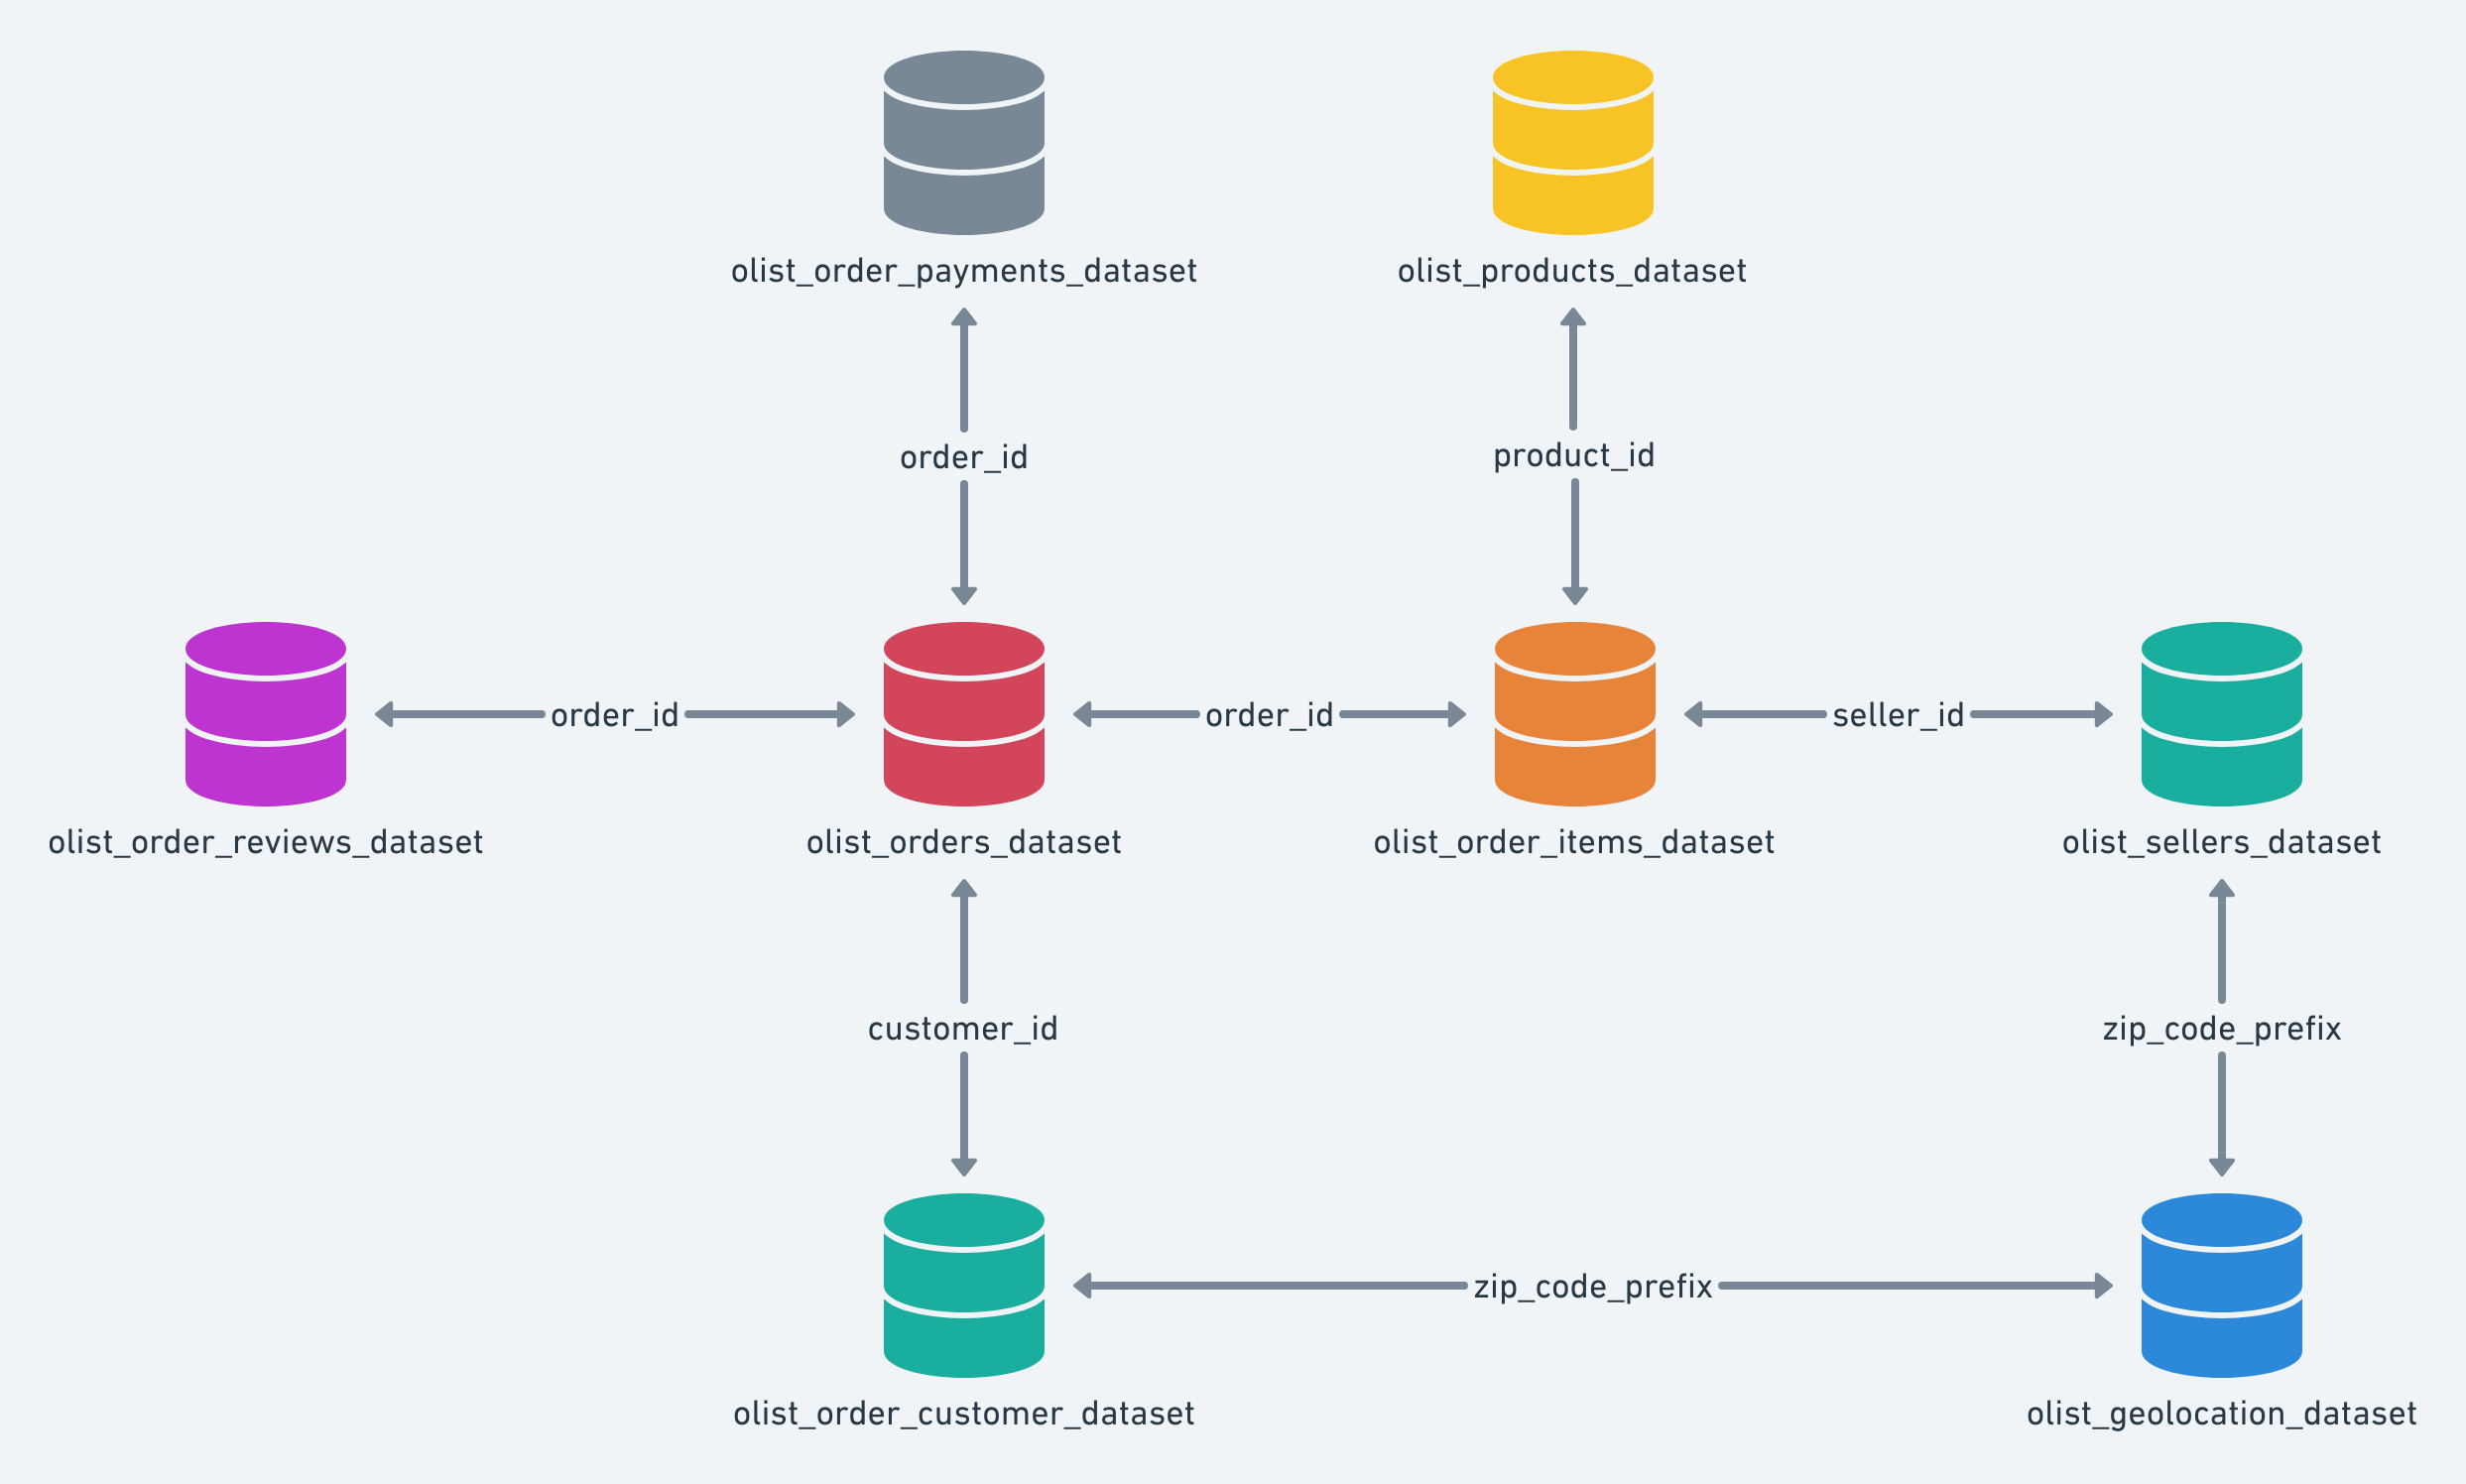

# Section A — Customer & Geographic Analysis

In [ ]:
customer_orders = pd.merge(orders,customers,on = 'customer_id', how = 'left')

**Dataset Inspection**

In [ ]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


# Checking The Dataset

In [ ]:
customer_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
 8   customer_unique_id             99441 non-null  object
 9   customer_zip_code_prefix       99441 non-null  int64 
 10  customer_city                  99441 non-null  object
 11  customer_state                 99441 non-null  object
dtypes: int64(1), object(11)
memory usage: 9.1+ MB


In [ ]:
customer_orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [ ]:
customer_orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


# Orders by State and Customer Distribution (Where Customers Are Located)

In [ ]:
order_by_state = (
    customer_orders
    .groupby('customer_state')
    .agg({
        'order_id': 'nunique',            # total orders
        'customer_unique_id': 'nunique'   # total customers
    })
    .rename(columns={
        'order_id': 'total_orders',
        'customer_unique_id': 'total_customers'
    })
    .sort_values(by='total_orders', ascending=False)
)

order_by_state.head(10)


,total_orders,total_customers
customer_state,,
SP,41746,40302
RJ,12852,12384
MG,11635,11259
RS,5466,5277
PR,5045,4882
SC,3637,3534
BA,3380,3277
DF,2140,2075
ES,2033,1964


# Orders VS Customer by State


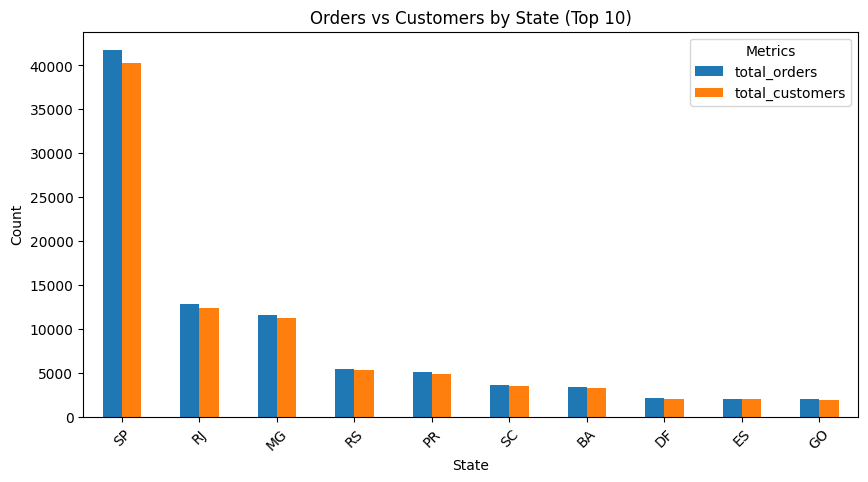

In [ ]:
order_by_state.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Orders vs Customers by State (Top 10)')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.show()



In [ ]:
# Count how many orders each customer made
orders_per_customer = (
    customer_orders.groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='total_orders').sort_values(by = 'total_orders',ascending=False)
)


In [ ]:
orders_per_customer

,customer_unique_id,total_orders
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
76082,ca77025e7201e3b30c44b472ff346268,7
...,...,...
32505,5656a8fabc8629ff96b2bc14f8c09a27,1
32504,56560124a5cc70119deb685775639ea7,1
32503,5655ee330a79bd1fd1e5fb220c2436dd,1
32502,5655967ad654dc2d2affca3502631db7,1


In [ ]:
orders_per_customer['total_orders'].value_counts().sort_index()


,count
total_orders,
1,93099
2,2745
3,203
4,30
5,8
6,6
7,3
9,1
17,1


In [ ]:
repeat_customers = orders_per_customer[orders_per_customer['total_orders'] > 1]


In [ ]:
total_customers = orders_per_customer.shape[0]
repeat_customer_count = repeat_customers.shape[0]

repeat_purchase_rate = (repeat_customer_count / total_customers) * 100

print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")


Repeat Purchase Rate: 3.12%


# Key Insights
---


1.   The business is highly concentrated in São Paulo (SP), which contributes the majority of customers and orders, creating regional dependency.

2.   Other states such as RJ and MG show strong but underutilized demand, while southern and emerging states present clear expansion opportunities.
3.   Customer behavior is largely transactional rather than loyal, with a repeat purchase rate of only 3.12%.


4.   Nearly all customers make a single purchase, indicating weak post-purchase engagement and low customer lifetime value.

# Business Recommendations

---

| **Action**                                                           | **Rationale (Why?)**                                                                                              | **Expected Business Impact**                                               |
| -------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| Launch 2nd-Purchase Discounts                                     | 97% of customers purchase only once (Repeat Rate = 3.12%). Incentivizing the second order builds habit formation. | Increase repeat purchase rate → Higher Customer Lifetime Value (CLV).      |
| Implement Post-Purchase Engagement (Email / SMS / WhatsApp)       | Customers disengage after first order due to lack of follow-up communication.                                     | Improve retention and bring customers back at low marketing cost.          |
| Introduce Loyalty / Rewards Program                                | No strong reason currently exists for customers to stay loyal.                                                    | Encourages long-term relationships and increases multi-order customers.    |
| Improve First-Order Experience (Delivery Speed, Updates, Support) | First experience strongly influences whether a customer returns.                                                  | Reduce churn after first purchase → Higher satisfaction & retention.       |
|  Expand Marketing in RJ, MG, PR (High Potential States)            | Demand already exists but is under-leveraged compared to SP.                                                      | Diversifies revenue base and reduces dependence on São Paulo.              |
| Shift KPI Focus from “Total Orders” to “Repeat Customers”         | Current growth depends heavily on acquiring new users (expensive model).                                          | Builds sustainable growth through retention rather than acquisition spend. |
| 🛍 Use Personalized Recommendations                                  | Customers are not being guided to relevant next purchases.                                                        | Drives cross-sell / upsell → More orders per customer.                     | **bold text**











# **Section B — Product & Revenue Performance**

In [ ]:
product_sales = pd.merge(orders,items,on = 'order_id',how = 'left')
product_sales = product_sales.merge(products,on = 'product_id',how='left')

In [ ]:
product_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [ ]:
list(product_sales.columns)


['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [ ]:
# Keep only useful columns
product_sales = product_sales[[
    'order_id',
    'product_id',
    'seller_id',
    'price',
    'freight_value',
    'product_category_name',
    'order_purchase_timestamp'
]]

In [ ]:
product_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  113425 non-null  object 
 1   product_id                112650 non-null  object 
 2   seller_id                 112650 non-null  object 
 3   price                     112650 non-null  float64
 4   freight_value             112650 non-null  float64
 5   product_category_name     111047 non-null  object 
 6   order_purchase_timestamp  113425 non-null  object 
dtypes: float64(2), object(5)
memory usage: 6.1+ MB


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
product_sales.isnull().sum()

,0
order_id,0
product_id,775
seller_id,775
price,775
freight_value,775
product_category_name,2378
order_purchase_timestamp,0


In [ ]:
#Rename Columns

product_sales.rename(columns={
    'price': 'product_price',
    'freight_value': 'shipping_cost',
    'product_category_name': 'category'
}, inplace=True)


In [ ]:
product_sales[product_sales['category'].isna()]

,order_id,product_id,seller_id,product_price,shipping_cost,category,order_purchase_timestamp
6,136cce7faa42fdb2cefd53fdc79a6098,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,49.90,16.05,NaN,2017-04-11 12:22:08
122,bfe42c22ecbf90bc9f35cf591270b6a7,71225f49be70df4297892f6a5fa62171,e5a3438891c0bfdb9394643f95273d8e,27.30,15.10,NaN,2018-01-27 22:04:34
212,58ac1947c1a9067b9f416cba6d844a3f,9820e04e332fc450d6fd975befc1bc28,520b493b57809f446cb0a233bb3e25c7,110.00,14.16,NaN,2017-09-13 09:18:50
264,e22b71f6e4a481445ec4527cb4c405f7,3bc5164bc7f4be77002d6651da65c98c,6cd68b3ed6d59aaa9fece558ad360c0a,22.50,11.74,NaN,2017-04-22 13:48:18
303,a094215e786240fcfefb83d18036a1cd,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,122.99,9.06,NaN,2018-02-08 18:56:45
...,...,...,...,...,...,...,...
113204,aaab15da689073f8f9aa978a390a69d1,NaN,NaN,NaN,NaN,NaN,2018-01-16 14:27:59
113236,3a3cddda5a7c27851bd96c3313412840,NaN,NaN,NaN,NaN,NaN,2018-08-31 16:13:44
113324,a89abace0dcc01eeb267a9660b5ac126,NaN,NaN,NaN,NaN,NaN,2018-09-06 18:45:47
113325,a69ba794cc7deb415c3e15a0a3877e69,NaN,NaN,NaN,NaN,NaN,2017-08-23 16:28:04


In [ ]:
product_sales = product_sales[~product_sales['category'].isna()]

In [ ]:
product_sales

,order_id,product_id,seller_id,product_price,shipping_cost,category,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria,2018-02-13 21:18:39
...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,174.90,20.10,bebes,2018-02-06 12:58:58
113421,83c1379a015df1e13d02aae0204711ab,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,205.99,65.02,eletrodomesticos_2,2017-08-27 14:46:43
113422,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,informatica_acessorios,2018-01-08 21:28:27
113423,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,179.99,40.59,informatica_acessorios,2018-01-08 21:28:27


In [ ]:
product_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111047 entries, 0 to 113424
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  111047 non-null  object 
 1   product_id                111047 non-null  object 
 2   seller_id                 111047 non-null  object 
 3   product_price             111047 non-null  float64
 4   shipping_cost             111047 non-null  float64
 5   category                  111047 non-null  object 
 6   order_purchase_timestamp  111047 non-null  object 
dtypes: float64(2), object(5)
memory usage: 6.8+ MB


In [ ]:
product_sales['revenue'] = product_sales['product_price'] + product_sales['shipping_cost']


# Top-Selling Categories (By Order Volume) Vs Revenue


In [ ]:
top_categories = (product_sales.groupby('category')
    .agg({'order_id': 'nunique',
          'revenue': 'sum'
          })
    .rename(columns={'order_id': 'total_orders_quantity'})
    .sort_values(by = 'total_orders_quantity',ascending=False)
    .reset_index()
    .head(10)
    )
top_categories


,category,total_orders_quantity,revenue
0,cama_mesa_banho,9417,1241681.72
1,beleza_saude,8836,1441248.07
2,esporte_lazer,7720,1156656.48
3,informatica_acessorios,6689,1059272.40
4,moveis_decoracao,6449,902511.79
5,utilidades_domesticas,5884,778397.77
6,relogios_presentes,5624,1305541.61
7,telefonia,4199,394883.32
8,automotivo,3897,685384.32
9,brinquedos,3886,561372.55


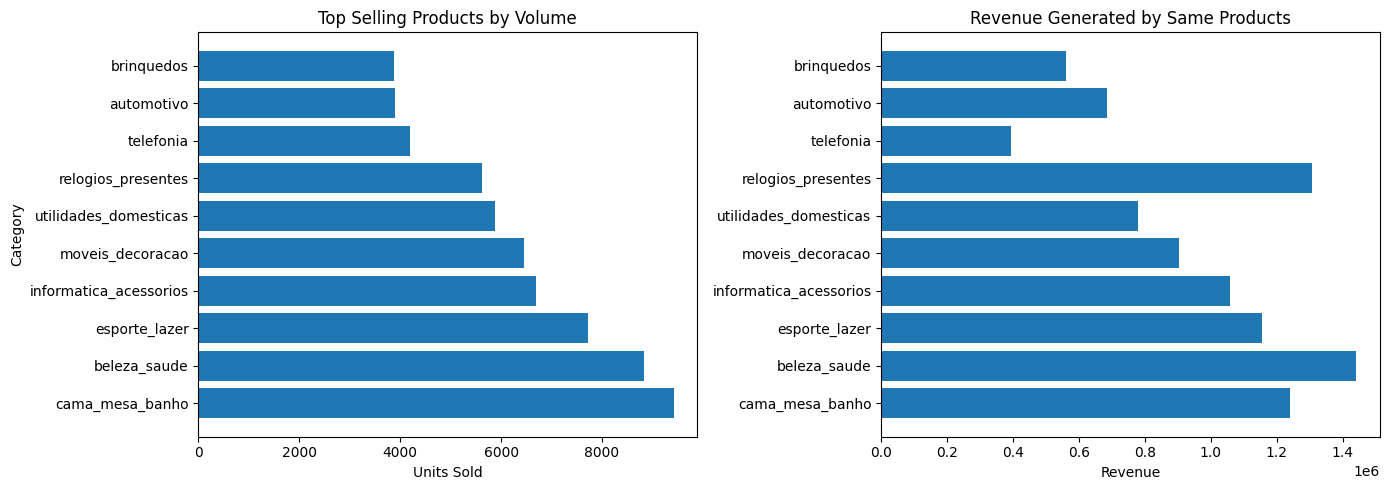

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Volume Plot
axes[0].barh(top_categories['category'], top_categories['total_orders_quantity'])
axes[0].set_title('Top Selling Products by Volume')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Category')

# Revenue Plot
axes[1].barh(top_categories['category'], top_categories['revenue'])
axes[1].set_title('Revenue Generated by Same Products')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# **Business Recommendations Based on Analysis**




| **Category**               | **Observation**                                            | **Strategic Action**                                            | **Expected Business Impact**                                   |
| -------------------------- | ---------------------------------------------------------- | --------------------------------------------------------------- | -------------------------------------------------------------- |
| **cama_mesa_banho**        | Highest in both sales and revenue (core category).         | Ensure strong inventory planning and prioritize ads/visibility. | Sustains primary revenue engine and prevents stock-outs.       |
| **beleza_saude**           | High demand with strong revenue contribution.              | Launch loyalty programs and subscription-style offers.          | Drives repeat purchases and increases customer lifetime value. |
| **esporte_lazer**          | Balanced performance across volume and value.              | Use targeted seasonal promotions and bundles.                   | Expands growth without heavy discounting.                      |
| **informatica_acessorios** | Consistent demand with good revenue potential.             | Introduce cross-sell (accessories, upgrades).                   | Increases basket size and monetizes tech buyers.               |
| **moveis_decoracao**       | Moderate sales but higher ticket size.                     | Highlight premium positioning and financing options.            | Improves conversion for high-value purchases.                  |
| **utilidades_domesticas**  | Functional, repeat-use category with stable demand.        | Offer combo deals and multipacks.                               | Encourages higher order value and repeat buying.               |
| **relogios_presentes**     | Lower volume but very high revenue (premium behavior).     | Focus on premium branding and gifting campaigns.                | Maximizes margin and attracts high-value customers.            |
| **telefonia**              | High sales but weaker revenue (price-sensitive).           | Bundle accessories or upsell higher-spec products.              | Converts traffic-heavy category into profit contributor.       |
| **automotivo**             | Moderate demand with steady value.                         | Run targeted niche marketing (enthusiast segments).             | Strengthens category specialization and loyalty.               |
| **brinquedos**             | High volume but low average price (entry-level purchases). | Use as acquisition category and cross-sell complementary items. | Brings new customers and increases multi-item orders.          |


# **Section C — Delivery Performance Analysis**

In [ ]:
delivery_geo = orders.merge(customers, on='customer_id', how='left')
delivery_geo = delivery_geo.merge(items, on='order_id', how='left')
delivery_geo = delivery_geo.merge(products, on='product_id', how='left')


In [ ]:
# Keep only useful columns
delivery_geo = delivery_geo[[
    'order_id',
    'customer_state',
    'product_category_name',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]]


In [ ]:
delivery_geo['order_purchase_timestamp'] = pd.to_datetime(delivery_geo['order_purchase_timestamp'])
delivery_geo['order_delivered_customer_date'] = pd.to_datetime(delivery_geo['order_delivered_customer_date'])
delivery_geo['order_estimated_delivery_date'] = pd.to_datetime(delivery_geo['order_estimated_delivery_date'])

# Calculate Delivery & Delay Days

In [ ]:
delivery_geo['delivery_days'] = (
    delivery_geo['order_delivered_customer_date'] -
    delivery_geo['order_purchase_timestamp']
).dt.days

delivery_geo['delay_days'] = (
    delivery_geo['order_delivered_customer_date'] -
    delivery_geo['order_estimated_delivery_date']
).dt.days


In [ ]:
delivery_geo['is_delayed'] = delivery_geo['delay_days'] > 0


# Avg Delivery Time by State

In [ ]:
state_delivery = (
    delivery_geo.groupby('customer_state')['delivery_days']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


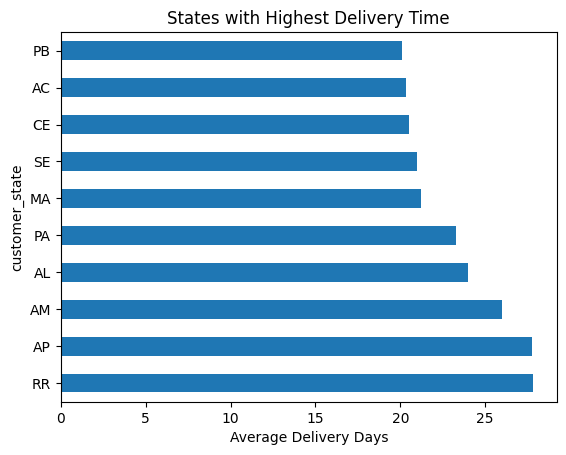

In [ ]:
state_delivery.plot(kind='barh')
plt.title('States with Highest Delivery Time')
plt.xlabel('Average Delivery Days')
plt.show()


# Late Delivery Rate by State

In [ ]:
state_delay_rate = (
    delivery_geo.groupby('customer_state')['is_delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
state_delay_rate

,is_delayed
customer_state,
AL,0.199552
MA,0.173285
SE,0.156410
PI,0.130515
CE,0.130464
BA,0.114630
RJ,0.112073
PA,0.109677
ES,0.105565


# Product-Level Delay Analysis

In [ ]:
category_delivery = (
    delivery_geo.groupby('product_category_name')['delivery_days']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


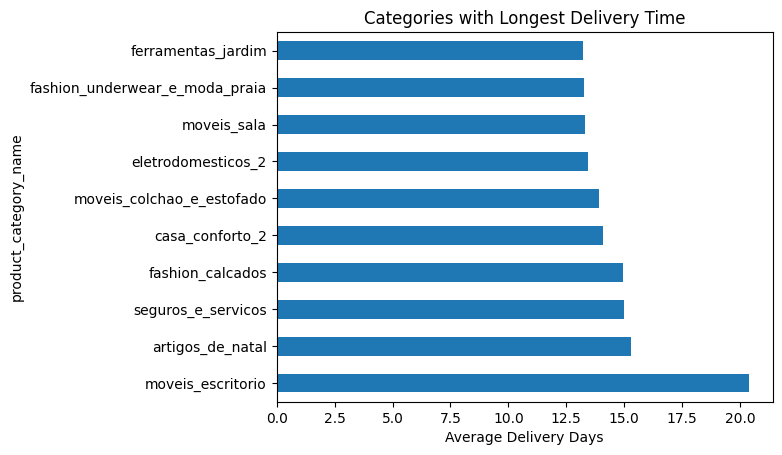

In [ ]:
category_delivery.plot(kind='barh')
plt.title('Categories with Longest Delivery Time')
plt.xlabel('Average Delivery Days')
plt.show()


# Delay Rate by Category

In [ ]:
category_delay_rate = (
    delivery_geo.groupby('product_category_name')['is_delayed']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
category_delay_rate

,is_delayed
product_category_name,
casa_conforto_2,0.133333
moveis_colchao_e_estofado,0.131579
audio,0.115385
artigos_de_natal,0.098039
casa_conforto,0.092166
fashion_underwear_e_moda_praia,0.091603
livros_tecnicos,0.078652
moveis_escritorio,0.078652
eletronicos,0.074810


# **Business Recommendations Based on Analysis**


| Category                                                                | Observation                                                                                                            | Strategic Action                                                                                              | Expected Business Impact                                                                  |
| ----------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **High-Delay States (AL, MA, SE, PI, CE)**                              | These regions show the highest delay ratios (10–20%). Indicates weak last-mile logistics or long-distance fulfillment. | Create **regional fulfillment hubs** or partner with **local courier services** to shorten delivery distance. | Reduce delivery time by 15–25%, improving customer satisfaction and repeat purchase rate. |
| **Moderate-Delay States (BA, RJ, PA, ES, PB)**                          | Delays exist but are operationally manageable. Likely due to demand spikes or routing inefficiencies.                  | Implement **route optimization & dynamic carrier allocation** during peak periods.                            | Lower logistics cost while stabilizing delivery SLA performance.                          |
| **Furniture Categories (moveis_colchao_e_estofado, moveis_escritorio)** | Bulky items consistently show higher delays due to handling and freight complexity.                                    | Use **scheduled delivery windows + specialized heavy-goods carriers**. Pre-position stock regionally.         | Faster fulfillment of large items, fewer cancellations/returns.                           |
| **Home Comfort Products (casa_conforto_2, casa_conforto)**              | Delay driven by supplier-side dispatch latency rather than transportation.                                             | Introduce **vendor SLA agreements + automated dispatch tracking**.                                            | Improves supply chain reliability and reduces processing delays.                          |
| **Seasonal Products (artigos_de_natal)**                                | Delay risk rises during seasonal demand surges.                                                                        | Apply **demand forecasting + temporary micro-warehousing** before peak season.                                | Prevents seasonal backlog and captures full peak revenue opportunity.                     |
| **Fashion Categories (fashion_underwear_e_moda_praia)**                 | Moderate delays suggest fragmented suppliers and multi-origin shipping.                                                | Consolidate inventory into **fewer distribution nodes**.                                                      | Faster order consolidation → improved delivery predictability.                            |
| **Electronics & Audio**                                                 | Delays relatively lower but still sensitive due to high customer expectation.                                          | Prioritize **express shipping lanes** for high-value items.                                                   | Enhances premium customer experience and brand trust.                                     |
| **Books / Technical Items (livros_tecnicos)**                           | Stable but slower fulfillment from niche suppliers.                                                                    | Maintain **buffer stock for top SKUs**.                                                                       | Prevents avoidable delays with minimal inventory cost.                                    |


# **Section D — Customer Satisfaction Drivers**

In [ ]:
cust_sat = orders[['order_id','customer_id',
                   'order_purchase_timestamp',
                   'order_delivered_customer_date',
                   'order_estimated_delivery_date']]

cust_sat = cust_sat.merge(reviews[['order_id','review_score']], on='order_id', how='left')

cust_sat = cust_sat.merge(items[['order_id','price','freight_value']], on='order_id', how='left')

cust_sat = cust_sat.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')


In [ ]:
cust_sat['order_purchase_timestamp'] = pd.to_datetime(cust_sat['order_purchase_timestamp'])
cust_sat['order_delivered_customer_date'] = pd.to_datetime(cust_sat['order_delivered_customer_date'])
cust_sat['order_estimated_delivery_date'] = pd.to_datetime(cust_sat['order_estimated_delivery_date'])

In [ ]:
cust_sat['actual_delivery_days'] = (
    cust_sat['order_delivered_customer_date'] -
    cust_sat['order_purchase_timestamp']
).dt.days

cust_sat['estimated_delivery_days'] = (
    cust_sat['order_estimated_delivery_date'] -
    cust_sat['order_purchase_timestamp']
).dt.days

cust_sat['delivery_delay'] = (
    cust_sat['actual_delivery_days'] - cust_sat['estimated_delivery_days']
)

cust_sat['is_delayed'] = cust_sat['delivery_delay'] > 0


**1. Review Score vs Delivery Delay**

Does late delivery actually reduce ratings?

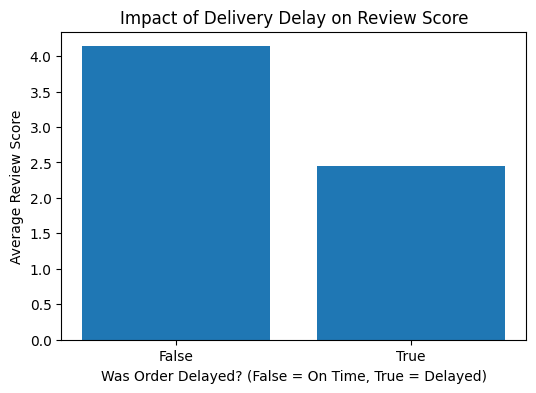

In [ ]:
delay_review = cust_sat.groupby('is_delayed')['review_score'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(delay_review['is_delayed'].astype(str), delay_review['review_score'])

plt.title('Impact of Delivery Delay on Review Score')
plt.xlabel('Was Order Delayed? (False = On Time, True = Delayed)')
plt.ylabel('Average Review Score')

plt.show()



**2. Review Score vs Freight Cost**

Do customers get angry when shipping is expensive?

In [ ]:
cust_sat['freight_bucket'] = pd.qcut(cust_sat['freight_value'], 4,
                                     labels=['Low','Medium','High','Very High'])

freight_review = cust_sat.groupby('freight_bucket')['review_score'].mean().reset_index()



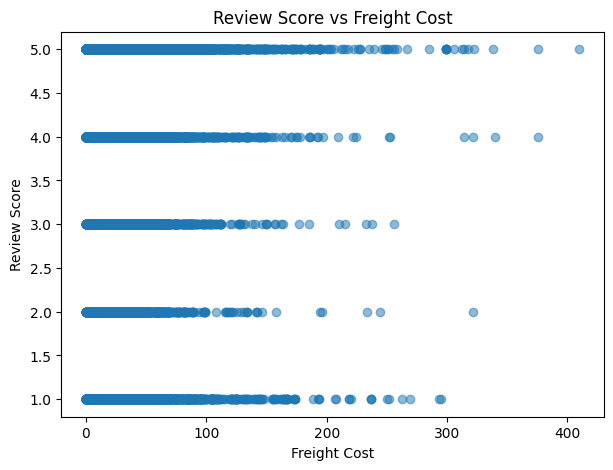

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(cust_sat['freight_value'], cust_sat['review_score'], alpha=0.5)

plt.title('Review Score vs Freight Cost')
plt.xlabel('Freight Cost')
plt.ylabel('Review Score')

plt.show()


3. Review Score vs Product Cost

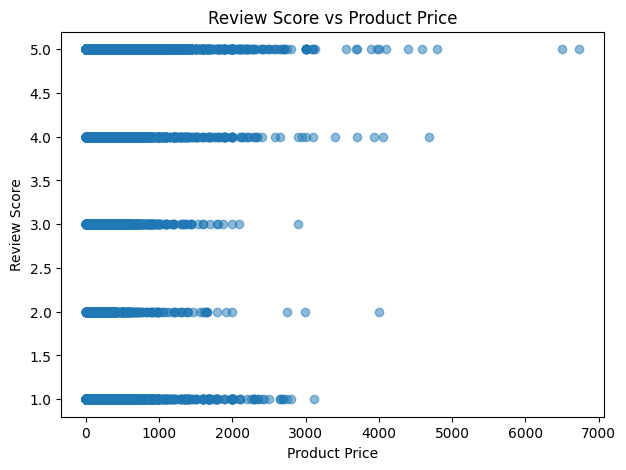

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(cust_sat['price'], cust_sat['review_score'], alpha=0.5)

plt.title('Review Score vs Product Price')
plt.xlabel('Product Price')
plt.ylabel('Review Score')

plt.show()


# **Business Recommendations — Customer Satisfaction Drivers**

| **Observation**                                                                                                           | **Action**                                                                                               | **Rationale**                                                                                         |
| ------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| Delivery delay shows a clear negative impact on ratings (delayed orders ≈ low review scores).                             | Prioritize on-time fulfillment through better logistics planning, regional warehouses, and courier SLAs. | Timely delivery is the strongest driver of satisfaction and repeat purchase behavior.                 |
| Freight cost shows weak relationship with review score — customers still give high ratings even at higher shipping costs. | Avoid over-discounting shipping; instead invest in reliable delivery and tracking experience.            | Customers value reliability over cheaper shipping, protecting margins while improving service.        |
| Product price has minimal correlation with satisfaction — expensive products are not rated worse.                         | Focus on product quality, packaging, and service rather than competing on price cuts.                    | Customers are willing to pay more if the experience meets expectations, enabling premium positioning. |
| Poor reviews are concentrated where service experience fails, not where pricing is high.                                  | Implement proactive communication (live tracking, delay alerts, support response).                       | Managing expectations reduces dissatisfaction even when operational issues occur.                     |
| Satisfaction is operationally driven rather than price-driven.                                                            | Shift KPIs from “lowest cost” to **delivery reliability, fulfillment speed, and experience metrics**.    | Experience-led strategy improves retention, lifetime value, and brand perception.                     |


# **Section E — Payment Behavior Analysis**

**How customers prefer to pay?**

In [ ]:
payment_analysis = orders.merge(payments, on='order_id', how='left')


In [ ]:
payment_analysis['payment_type'].value_counts()
payment_analysis.groupby('payment_type')['payment_value'].sum()


,payment_value
payment_type,
boleto,2869361.27
credit_card,12542084.19
debit_card,217989.79
not_defined,0.00
voucher,379436.87


**Payment Method Analysis — Business Recommendations**

| **Observation**                                                            | **Action**                                                                             | **Rationale**                                                                    | **Expected Business Impact**                               |
| -------------------------------------------------------------------------- | -------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- | ---------------------------------------------------------- |
| Credit Card dominates revenue contribution (~80%+ of total payment value). | Optimize credit card checkout with 1-click payment, EMI options, and fraud protection. | Customers clearly prefer fast, frictionless digital payments.                    | Higher conversion rate and increased average order value.  |
| Boleto is the 2nd largest contributor despite being an offline method.     | Reduce boleto confirmation time via automated reminders and faster validation.         | Boleto users are price-sensitive but high in volume; delays may cause drop-offs. | Capture otherwise lost sales and improve order completion. |
| Voucher usage is relatively low but meaningful.                            | Introduce targeted promotions using vouchers (cashback, seasonal campaigns).           | Vouchers are strong tools for acquisition and reactivation.                      | Boost repeat purchases and marketing ROI.                  |
| Debit card adoption is very low.                                           | Evaluate UX or bank compatibility issues; consider deprioritizing heavy investment.    | Customers may find debit less convenient compared to credit alternatives.        | Focus resources on high-performing payment channels.       |

# **Section F — Time-Based Sales Trends**

**1.Monthly Sales Trend (Growth / Seasonality)**

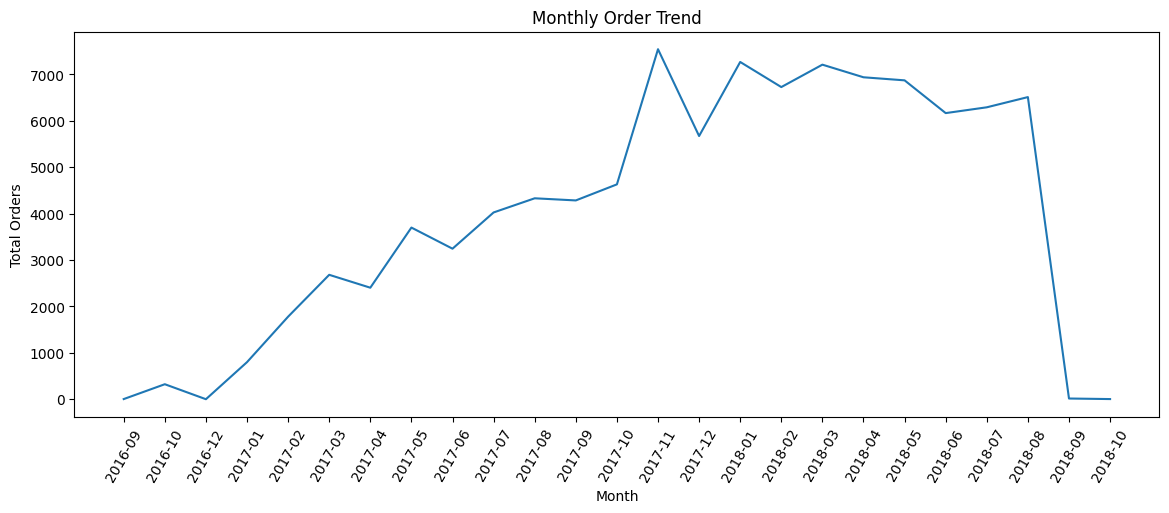

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

monthly_sales = (
    orders.groupby(orders['order_purchase_timestamp'].dt.to_period('M'))
    .size()
    .reset_index(name='total_orders')
)

monthly_sales['order_purchase_timestamp'] = monthly_sales['order_purchase_timestamp'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['order_purchase_timestamp'], monthly_sales['total_orders'])

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=60)
plt.show()


**2.Day-of-Week Pattern (Customer Buying Behavior)**

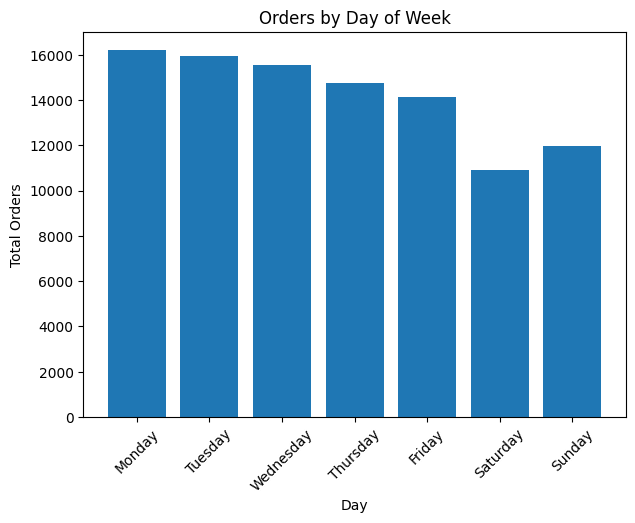

In [ ]:
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

dow_sales = orders['day_of_week'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(7,5))
plt.bar(dow_sales.index, dow_sales.values)

plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.show()


**3.Revenue Trend Over Time (Business Health)**

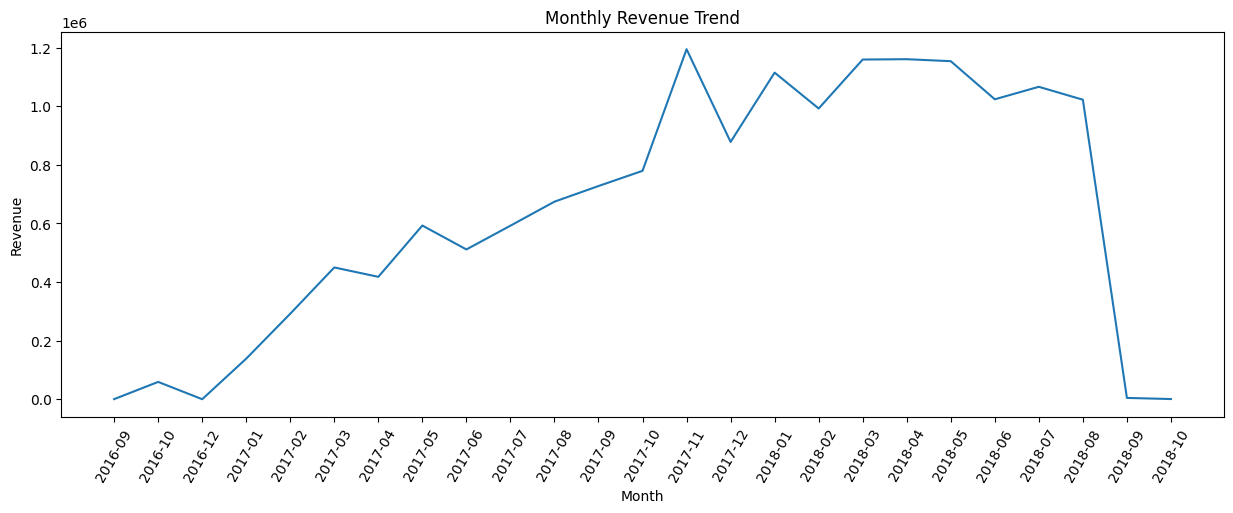

In [ ]:
sales_time = orders.merge(payments, on='order_id')

sales_time['month'] = sales_time['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = (
    sales_time.groupby('month')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(15,5))
plt.plot(monthly_revenue['month'], monthly_revenue['payment_value'])

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=60)
plt.show()


# **Business Recommendations**

| **Focus Area**    | **Observation (The “What”)**                                                       | **Strategic Action (The “How”)**                                                        | **Rationale (The “Why”)**                                                                                               |
| ----------------- | ---------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| **Systemic Risk** | Sudden 100% drop in Sept 2018 (Revenue & Orders).                                  | Conduct Root Cause Analysis (RCA): Audit API/data pipelines and check site uptime.      | Ensures we distinguish between an actual business failure vs. a data tracking issue before reporting insights.          |
| **Peak Demand**   | Monday is the highest sales day; volume gradually declines through Saturday.       | Front-load campaigns: Align new product launches and ad spend with Monday spikes.       | Leverages strong early-week purchase intent to maximize marketing ROI and conversions.                                  |
| **Growth Health** | Strong scaling observed across 2017–2018; revenue peaked around ~$1.2M.            | Shift focus to Customer Lifetime Value (LTV): Invest in retention and loyalty programs. | After achieving product-market fit, sustainable profitability comes from repeat customers rather than pure acquisition. |
| **Volatility**    | November 2017 saw a sharp spike followed by a December dip (“post-peak hangover”). | Implement inventory smoothing: Adjust Q4 safety stock and demand forecasting.           | Prevents peak-and-drop cycles and ensures consistent revenue flow during high-season periods.                           |


# **🎯 Final Business Conclusion**

This analysis revealed that the company’s growth is driven by strong customer acquisition,
but long-term profitability is constrained by operational inefficiencies rather than pricing.

Key Findings:

- Repeat purchase rate is low (3.12%) → retention opportunity.
- High-performing regions drive most revenue → geographic concentration risk.
- Some categories generate volume but not value → need margin strategy.
- Delivery delays significantly reduce customer satisfaction.
- Price and freight cost have minimal impact on reviews → experience matters more.
- Credit card dominates transactions → digital payment optimization required.
- Sales patterns show predictable demand cycles → opportunity for smarter campaign planning.

---

## 📈 Strategic Recommendation

The company should shift from a **discount-driven growth model**
to an **operations-led customer experience strategy**, focusing on:

✔ Faster and more reliable delivery  
✔ Retention programs to increase lifetime value  
✔ Targeted regional expansion  
✔ Category-level profitability optimization  
✔ Demand-aligned marketing execution

---

## 💡 Business Impact

Improving fulfillment reliability and retention mechanisms will generate
higher ROI than price reductions, leading to sustainable, experience-driven growth.
